In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("dataset_segmentacion_clientes.csv")

df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


In [3]:
print(df.shape)

df.info()

(700, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


In [4]:
X = df[[
    'purchase_freq_month',
    'avg_basket_usd',
    'time_on_site_min',
    'discount_sensitivity',
    'returns_rate'
]]

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
inercia = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(X_scaled)
    inercia.append(modelo.inertia_)

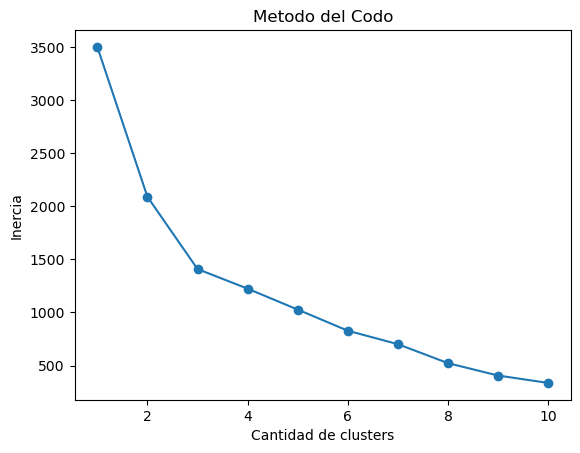

In [7]:
plt.plot(range(1, 11), inercia, marker='o')

plt.title("Metodo del Codo")
plt.xlabel("Cantidad de clusters")
plt.ylabel("Inercia")

plt.show()

Observando el gráfico del método del codo, se puede notar que el valor K=3 es el más adecuado para el modelo. A partir de ese punto, la reducción de la inercia comienza a disminuir de forma más gradual, indicando que agregar más clusters no mejora significativamente el agrupamiento.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(X_scaled)

In [9]:
df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform,cluster
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905,0
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460,0
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173,1
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026,2
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522,1


El gráfico muestra la agrupación de clientes según la frecuencia de compra y el ticket promedio. Se pueden observar tres grupos diferenciados, donde cada color representa un cluster distinto generado automáticamente por el algoritmo K-Means.

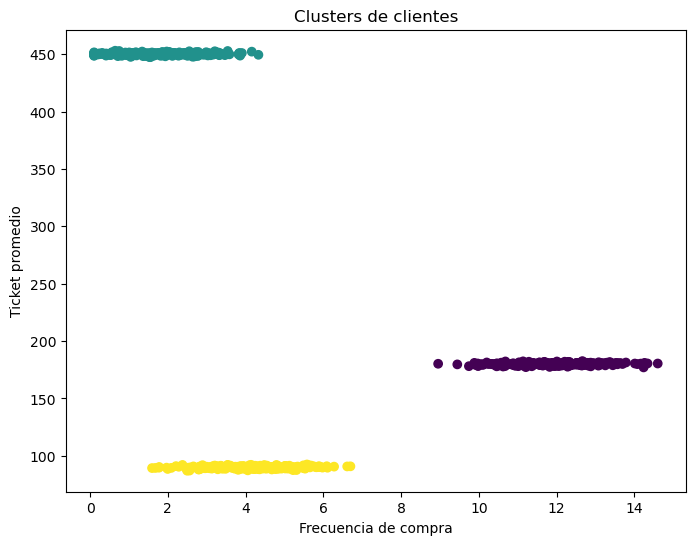

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['purchase_freq_month'],
    df['avg_basket_usd'],
    c=df['cluster']
)

plt.xlabel("Frecuencia de compra")
plt.ylabel("Ticket promedio")
plt.title("Clusters de clientes")

plt.show()

In [11]:
df.groupby('cluster').mean()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
cluster,,,,,,,
0,11.961153,179.999315,35.022131,0.541539,0.332461,0.046581,-0.039583
1,1.846908,450.123746,5.973739,0.358088,0.375371,0.052026,0.123291
2,4.091883,89.957567,10.003793,0.379465,0.298761,-0.032045,-0.132205


Conclusión

En esta actividad se aplicó el algoritmo K-Means para realizar segmentación de clientes utilizando variables relacionadas con hábitos de compra y comportamiento.

Primero se realizó el escalado de datos y luego se utilizó el método del codo para determinar la cantidad adecuada de clusters. A partir del análisis del gráfico, se eligió K=3 como valor óptimo.

Los resultados permitieron identificar diferentes perfiles de clientes. Un grupo presenta alta frecuencia de compra y ticket elevado, mientras que otros grupos muestran comportamientos más moderados o menor actividad de compra.

El algoritmo permitió encontrar patrones automáticamente sin necesidad de etiquetas previas, demostrando cómo funciona el aprendizaje no supervisado en problemas de clustering.